
# Przygotowanie

Przygotowanie
Przed rozpoczęciem pracy z notatnikiem proszę zmienić jego nazwę dodając na początku numer albumu, imię i nazwisko. {nr_albumu}_{imię}_{nazwisko}_{nazwa}

Po wykonaniu wszystkich zadań proszę przesłać wypełniony notatnik przez platformę ELF za pomocą formularza "Prześlij projekt" w odpowiedniej sekcji.

# Support Vector Machine

Jest to jeden z najbardziej rozpowszechnionych i wszechstronnych modeli uczenia maszynowego. Z jego uzyciem dokonac mozna klasyfikacji liniowej (SVC), nieliniowej jak i regresji (SVR). Na poniższej grafice przedstawione zostało działanie klasyfikatora.

![svc](svc.png)

Analizujac grafike dostrzec mozna dwie oddzielne klasy oddzielone za pomoca prostej. Widoczna linia ciagła rozdziela klasy, a przerywane linie oznaczają margines, czyli możliwe najdalsze oddalenie elementu (np. nowego) jaki zakwalifikowany
zostanie do danej klasy. Maszyny SVM czułe sa na skale danych, przed ich uzyciem zawsze powinna zostać przeprowadzona normalizacja danych (np. min-max, lub standaryzacja).

![svc_example](svc2.jpg)

Równowage pomiedzy marginesami możemy regulować za pomoca hipermarapetru
C. Mniejsze jego wartości poszerzają granice, jednocześnie wprowadzając
więcej jej naruszeń. Im margines jest szerszy, tym własciwosci generalizujace
jakie posiada klasyfikator będę większe. Mniejsza staje się podatność na przeuczenie
(ang. overfitting), ale zmniejsza się skuteczność klasyfikatora. Szukany jest
taki klasyfikator, który podzieli przestrzeń na dwa rozłaczne zbiory odpowiadajace
dwóm klasom, w możliwie optymalny sposób. Podejście opiera się na
znalezieniu granicy decyzyjnej.

Wektory nośne (Support vectors) są to obserwacje (data points), które wystepują najbliżej hiperpłaszczyzny. Punkty te, pomagają lepiej wyznaczyć linię separacji pomiędzy klasami poprzez obliczenie marginesów. Są to najbardziej znaczace obserwacje ze zbioru z punktu widzenia konstrukcji klasyfikatora.

Warto zaznaczyć, że za pomocą klasyfikatora SVC można klasyfikaować dane, które nie są linowo separowalne. Można to osiągnąć przez tzw "sztuczkę kernelową", dzięki czemu możliwe jest zmapowanie obserwacji do wielowymiarowej przestrzeni. Klasyfikator z biblioteki Sklearn posiada parametr *kernel*, który pozwala na zmianę jądra. Dodatkowo, parametr *gamma* pozwala na modyfikację działania samego kernela.

Warto zaznaczyć, że SVC dobrze nadaje się do niewielkich zbiorów danych, gdyż w przypadku dużej ilości staję się on mało wydajny.

Funkcja jaka jest minimalizowana podczas działania klasyfikatora wygląda następująco:

\begin{equation}
min C \sum^m_{i=1}[y^{(i)}cost_{1}(\theta^{T}x^{(i)}) - (1 - y^{(i)})cost_{0}(\theta^{T}x^{(i)})] + \frac{1}{2} \sum^{n}_{i=1}\theta^{2}_{j}
\end{equation}

## Zadanie 0 

Wczytanie danych ze zbioru oraz wizualizacja.

In [1]:
import pandas as pd

data_input = pd.read_csv('./Ankieta.csv')
data_input.head()

,waga,wzrost,plec
0,55,160,Kobieta
1,78,180,Mezczyzna
2,55,150,Kobieta
3,99,196,Mezczyzna
4,90,180,Mezczyzna


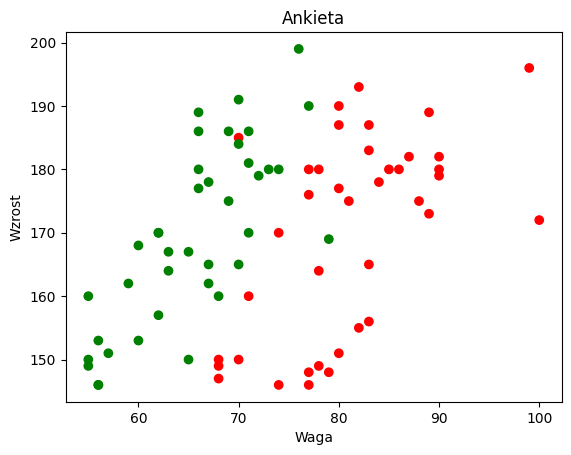

In [2]:
import matplotlib.pyplot as plt
from matplotlib import colors

data_input['plec'] = data_input['plec'].map(lambda x: 1 if x == 'Kobieta' else 0)

x = data_input['plec']
y = data_input['waga']
z = data_input['wzrost']

plt.scatter(y, z, c=x, cmap=colors.ListedColormap(['red', 'green']))
plt.xlabel('Waga')
plt.ylabel('Wzrost')
plt.title('Ankieta')
plt.show()

C:\Users\Piotr\AppData\Local\Temp\ipykernel_6952\1618543461.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data_input.hist(ax=ax)


array([[<Axes: title={'center': 'waga'}>,
        <Axes: title={'center': 'wzrost'}>],
       [<Axes: title={'center': 'plec'}>, <Axes: >]], dtype=object)

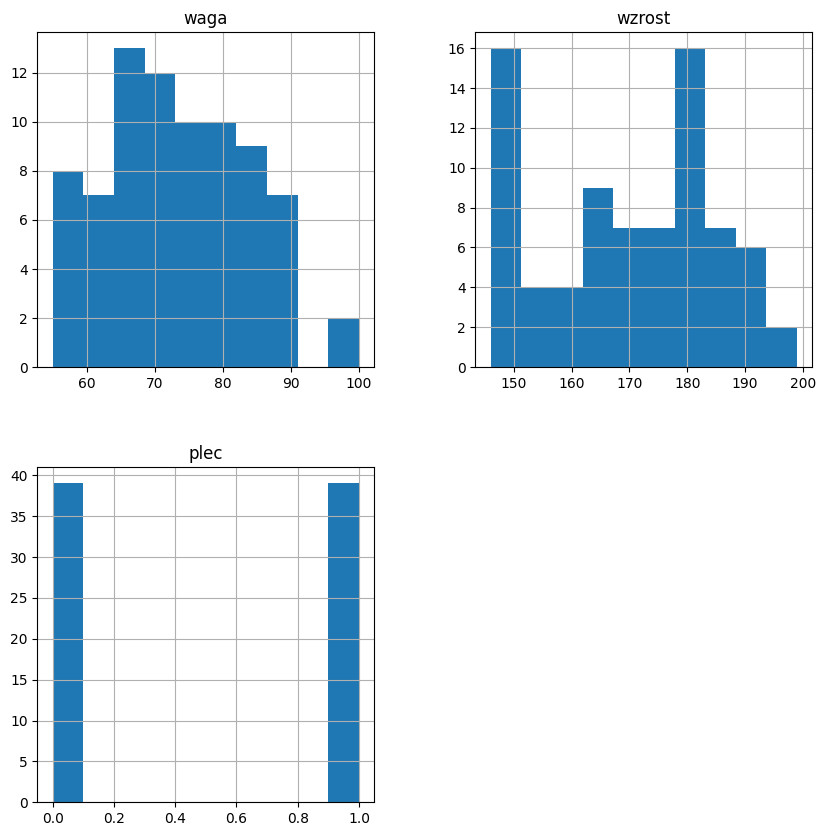

In [3]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize = (10,10))
ax = fig.gca()
data_input.hist(ax=ax)

<Axes: >

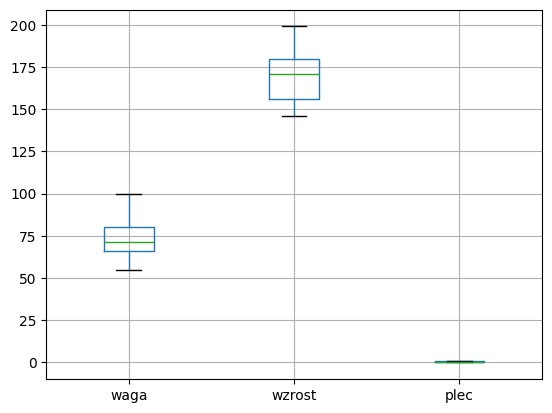

In [4]:
data_input.boxplot()

Na bazie wykresów box-plot można stwierdzić, że dane posiadają różniące się zakresy, co powoduje potrzebę ich skalowania. Warto zauważyć również, że rozkład klas w zbiorze jest równomierny (patrz: histogram)

## Zadanie 1

Proszę dokonać normalizacji zbioru danych za pomocą standaryzacji oraz narysować wykres box-plot dla wszystkich zmiennych. W jaki sposób zmieniły się dane? Co można powiedzieć o ich zakresach. W jakim celu dokonujemy normalizacji?

Średnia po standaryzacji:
 waga     -6.020825e-16
wzrost    4.554761e-16
plec      0.000000e+00
dtype: float64
Odchylenie standardowe po standaryzacji:
 waga      1.006473
wzrost    1.006473
plec      1.006473
dtype: float64


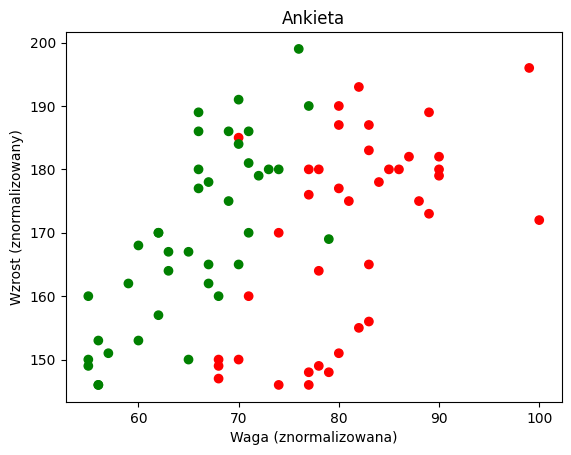

C:\Users\Piotr\AppData\Local\Temp\ipykernel_6952\951986584.py:28: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data_input.hist(ax=ax)


array([[<Axes: title={'center': 'waga'}>,
        <Axes: title={'center': 'wzrost'}>],
       [<Axes: title={'center': 'plec'}>, <Axes: >]], dtype=object)

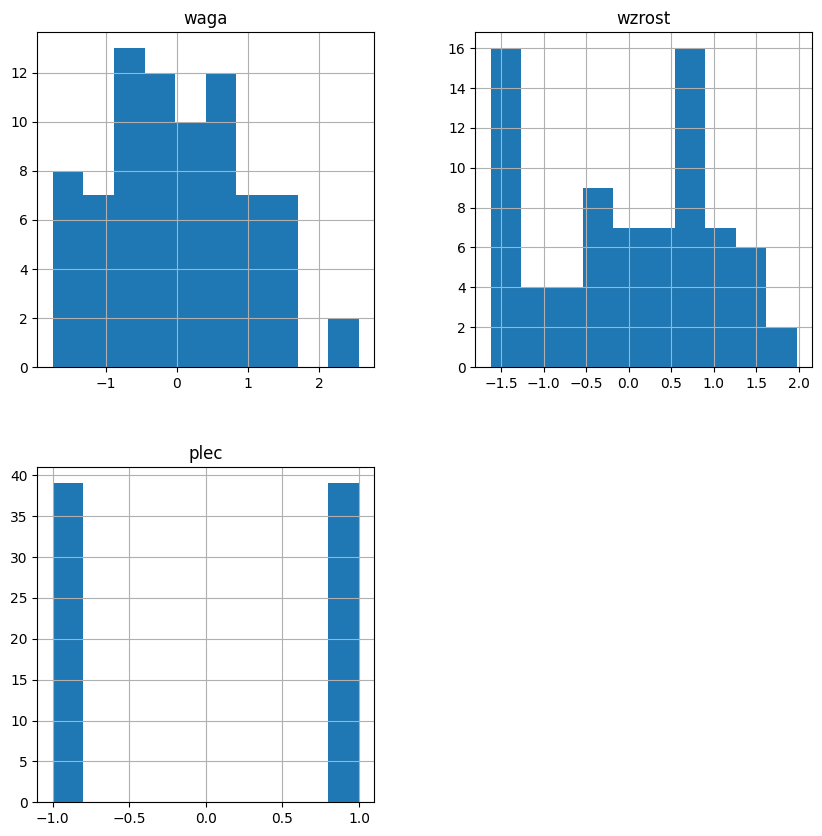

In [5]:
#INSERT YOUR CODE HERE
from sklearn.preprocessing import StandardScaler

data_input_original = data_input.copy()

# Przygotowanie zmiennych do wykresu
x = data_input['plec']
y = data_input['waga']
z = data_input['wzrost']

# Standaryzacja danych
scaler = StandardScaler()
data_input[['waga', 'wzrost', 'plec']] = scaler.fit_transform(data_input[['waga', 'wzrost', 'plec']])

# Analiza statystyk po standaryzacji
print("Średnia po standaryzacji:\n", data_input[['waga', 'wzrost', 'plec']].mean())
print("Odchylenie standardowe po standaryzacji:\n", data_input[['waga', 'wzrost', 'plec']].std())

# Wykres punktowy
plt.scatter(y, z, c=x, cmap=colors.ListedColormap(['red', 'green']))
plt.xlabel('Waga (znormalizowana)')
plt.ylabel('Wzrost (znormalizowany)')
plt.title('Ankieta')
plt.show()

fig = plt.figure(figsize = (10,10))
ax = fig.gca()
data_input.hist(ax=ax)

<Axes: >

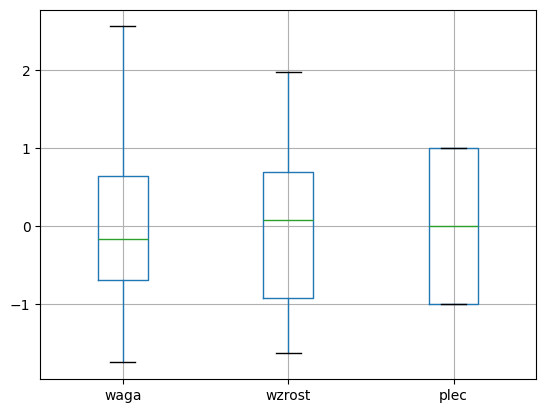

In [6]:
data_input.boxplot()

## Zadanie 2

W tym zadaniu należy dokonać podziału zbioru danych na uczący oraz testowy. Zbiór uczący będzie służył do treningu klasyfikatora, a testowy do obliczenia ostatecznej skuteczności klasyfikacji. Prosze, by 80% próbek znalazło się w zbiorze uczącym, a 20% w testowym. Proszę zadbać o odpowiednią inicjalizacje generatora pseudolosowego

In [7]:
# YOUR CODE HERE

from sklearn.model_selection import train_test_split

# Przygotowanie zmiennych wejściowych i docelowych
X = data_input[['waga', 'wzrost']]  # Zmienna wejściowa
y = x  # Zmienna docelowa (np. płeć)

# Podział danych na zbiór uczący i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

## Zadanie 3

W tym zadaniu należy dokonać klasyfikacji danych za pomocą klasyfikatora SVC. Proszę obliczyć skuteczność klasyfikatora na danych po, oraz przed standaryzacją i porównać wyniki.

In [12]:
from sklearn.svm import SVC

#YOUR CODE HERE

from sklearn.metrics import accuracy_score

X_original = data_input_original[['waga', 'wzrost']]  # Zmienna wejściowa
y_original = x  # Zmienna docelowa

# Podział danych na zbiór uczący i testowy
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(X_original, y_original, test_size=0.2,random_state=42)

# 1. SVC na danych przed standaryzacją
svc_no_scaling = SVC(random_state=42)
svc_no_scaling.fit(X_train_original, y_train_original)  # Trening na danych przed standaryzacją
y_pred_no_scaling = svc_no_scaling.predict(X_test_original)  # Predykcja na zbiorze testowym
accuracy_no_scaling = accuracy_score(y_test_original, y_pred_no_scaling)  # Skuteczność

# 2. SVC na danych po standaryzacji
svc_with_scaling = SVC(random_state=42)
svc_with_scaling.fit(X_train, y_train)  # Trening na danych po standaryzacji
y_pred_with_scaling = svc_with_scaling.predict(X_test)  # Predykcja na zbiorze testowym
accuracy_with_scaling = accuracy_score(y_test, y_pred_with_scaling)  # Skuteczność

# Wyniki
print(f"Skuteczność klasyfikatora SVC na danych przed standaryzacją: {accuracy_no_scaling:.4f}")
print(f"Skuteczność klasyfikatora SVC na danych po standaryzacji: {accuracy_with_scaling:.4f}")


Skuteczność klasyfikatora SVC na danych przed standaryzacją: 0.9375
Skuteczność klasyfikatora SVC na danych po standaryzacji: 0.9375


## Zadanie 4

Proszę dobrać odpowiedni parametr C (proszę spróbować z zakresu 0, 5 z krokiem co 0.5). Dla każdego C proszę wyrysować hiperpłaszczyznę utworzoną przez klasyfikator (w formie animimacji, lub inaczej). Proszę przedstawić na wykresie jak zmieniała się skuteczność klasyfikatora w zależności od parametru C. Jakie wnioski można wyciągnąć? Jak wpływa parametr C na wynik?

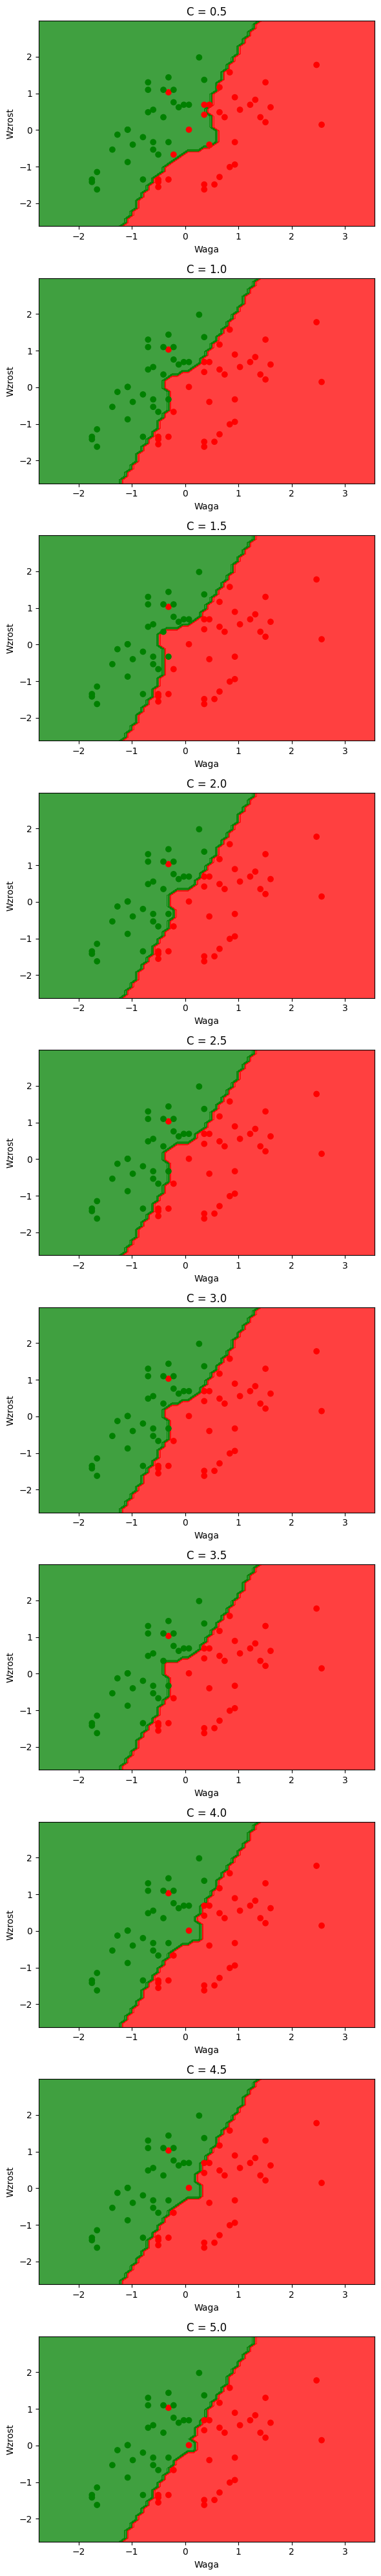

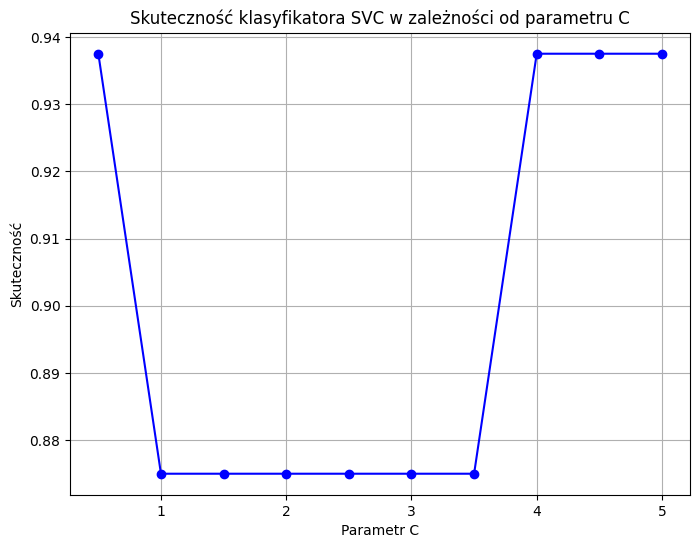

In [13]:
#YOUR CODE HERE

import numpy as np
from matplotlib.colors import ListedColormap

# Przygotowanie danych
X = data_input[['waga', 'wzrost']]  # Zmienna wejściowa
y = x  # Zmienna docelowa (np. płeć)

# Standaryzacja danych
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Podział na zbiór uczący i testowy
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Zakres wartości parametru C
C_values = np.arange(0.5, 5.5, 0.5)

# Przygotowanie wykresu do przedstawienia skuteczności
accuracy_scores = []

# Przygotowanie siatki do wizualizacji hiperpłaszczyzn
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Tworzenie wykresów dla różnych wartości C
fig, axes = plt.subplots(len(C_values), 1, figsize=(6, len(C_values) * 4))

for i, C in enumerate(C_values):
    ax = axes[i]
    
    # Trening klasyfikatora z parametrem C
    svc = SVC(kernel='poly', C=C)
    svc.fit(X_train, y_train)

    # Predykcja na zbiorze testowym
    y_pred = svc.predict(X_test)
    
    # Obliczenie skuteczności
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
    
    # Predykcja na siatce do wizualizacji hiperpłaszczyzny
    Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Wizualizacja hiperpłaszczyzny
    ax.contourf(xx, yy, Z, alpha=0.75, cmap=ListedColormap(['red', 'green']))
    scatter = ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=ListedColormap(['red', 'green']))
    ax.set_title(f"C = {C}")
    ax.set_xlabel('Waga')
    ax.set_ylabel('Wzrost')

plt.tight_layout()
plt.show()

# Wykres skuteczności w zależności od C
plt.figure(figsize=(8, 6))
plt.plot(C_values, accuracy_scores, marker='o', color='blue')
plt.title('Skuteczność klasyfikatora SVC w zależności od parametru C')
plt.xlabel('Parametr C')
plt.ylabel('Skuteczność')
plt.grid(True)
plt.show()


## Zadanie 5

Proszę dokonać pomiaru czasu wykonania algorytmu dla min. 2 różnych kerneli

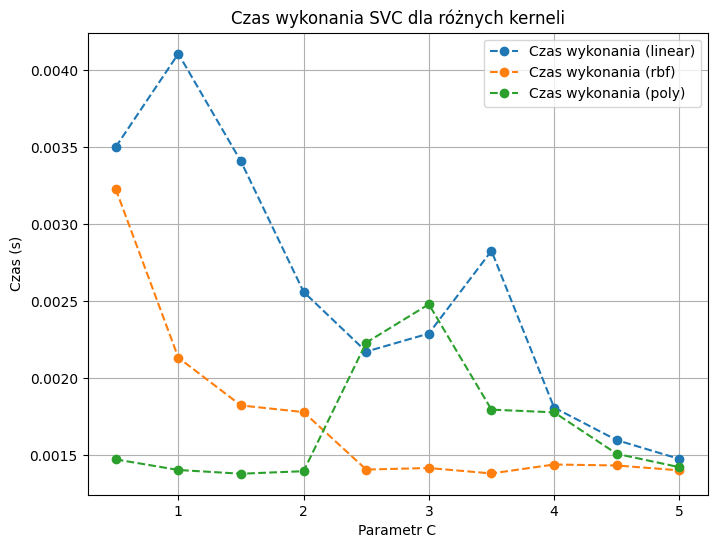

In [14]:
#YOUR CODE HERE

import time


# Zakres wartości parametru C
C_values = np.arange(0.5, 5.5, 0.5)

# Kernels do porównania
kernels = ["linear", "rbf", "poly"]
results = {}

for kernel in kernels:
    accuracy_scores = []
    times = []

    for C in C_values:
        start_time = time.time()
        
        # Trening klasyfikatora z danym kernelem
        svc = SVC(C=C, kernel=kernel, random_state=42)
        svc.fit(X_train, y_train)
        
        y_pred = svc.predict(X_test)
        
        accuracy = accuracy_score(y_test, y_pred)
        accuracy_scores.append(accuracy)
        
        end_time = time.time()  # Koniec pomiaru czasu
        times.append(end_time - start_time)

    results[kernel] = (accuracy_scores, times)

# Wykres czasu wykonania w zależności od C dla różnych kerneli
plt.figure(figsize=(8, 6))
for kernel in kernels:
    plt.plot(C_values, results[kernel][1], marker='o', linestyle='dashed', label=f'Czas wykonania ({kernel})')
plt.title('Czas wykonania SVC dla różnych kerneli')
plt.xlabel('Parametr C')
plt.ylabel('Czas (s)')
plt.legend()
plt.grid(True)
plt.show()


## Zadanie 6

Analiza wektorów nośnych (support vectors). Wyodrębnij wektory nośne z wytrenowanego modelu używając właściwości `.support_vectors_`. Zwizualizuj położenie wektorów nośnych na wykresie, jaki procent danych stanowią wektory nośne?

Wektory nośne stanowią 53.23% zbioru treningowego.


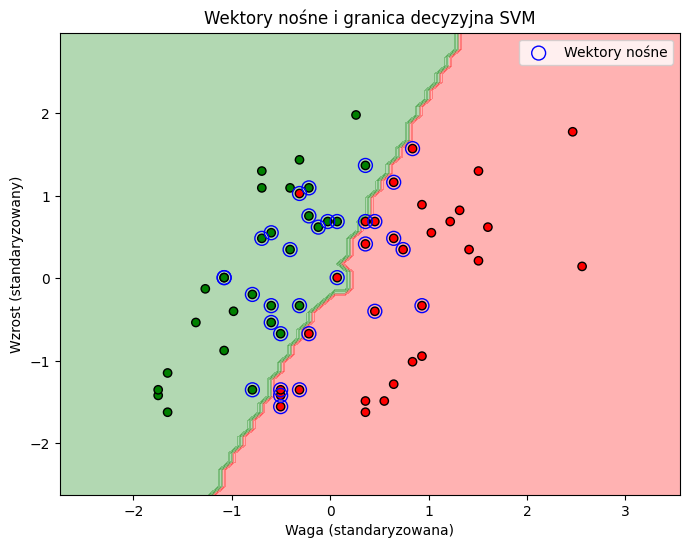

In [15]:
#YOUR CODE HERE

# Wybór modelu
svc = SVC(C=1.0, kernel='poly')
svc.fit(X_train, y_train)

# Predykcja
y_pred = svc.predict(X_test)

# Wyodrębnienie wektorów nośnych
support_vectors = svc.support_vectors_

# Obliczenie procentowego udziału wektorów nośnych
percent_support_vectors = (support_vectors.shape[0] / X_train.shape[0]) * 100
print(f"Wektory nośne stanowią {percent_support_vectors:.2f}% zbioru treningowego.")

# Wizualizacja
plt.figure(figsize=(8, 6))

# Rysowanie granicy decyzyjnej
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['red', 'green']))

# Rysowanie punktów danych
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=ListedColormap(['red', 'green']), edgecolor='k')

# Rysowanie wektorów nośnych
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=100, facecolors='none', edgecolors='blue', label="Wektory nośne")

plt.title('Wektory nośne i granica decyzyjna SVM')
plt.xlabel('Waga (standaryzowana)')
plt.ylabel('Wzrost (standaryzowany)')
plt.legend()
plt.show()


### Dla zbioru *dataR2* proszę dokonać podobnej analizy danych. Opis zbioru: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Coimbra

## Zadanie 7

Proszę zwizualizować dane dla 2 dowolnych zmiennych ze zbioru

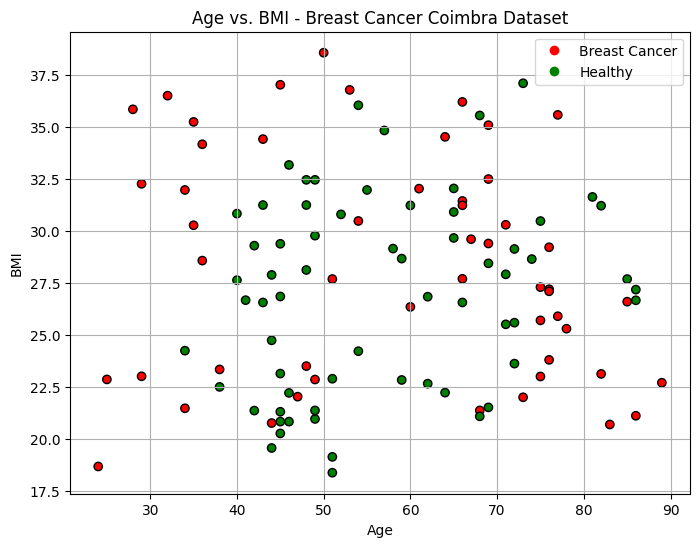

In [226]:
#YOUR CODE HERE

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Wczytaj plik CSV z lokalnego komputera
file_path = 'dataR2.csv'  # Zmień na właściwą ścieżkę
data = pd.read_csv(file_path)

# Tworzymy scatter plot dla Age i BMI
plt.figure(figsize=(8, 6))
scatter = plt.scatter(data['Age'], data['BMI'], c=data['Classification'], cmap=ListedColormap(['red', 'green']), edgecolor='k')

# Oznaczenia
plt.title('Age vs. BMI - Breast Cancer Coimbra Dataset')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.grid(True)
plt.legend(handles=scatter.legend_elements()[0], labels=['Breast Cancer', 'Healthy'])
plt.show()

## Zadanie 8

Proszę dokonać standaryzacji danych

In [227]:
#YOUR CODE HERE

# Separacja cech i etykiet
X = data.drop(columns=['Classification'])  # Wszystkie cechy oprócz klasyfikacji
y = data['Classification']  # Zmienna docelowa

# Standaryzacja danych
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Zadanie 9

Trenowanie klasyfikatora. Proszę dokonać treningu klasyfikatora na zbiorze treningowym (X_train, y_train). Proszę użyć różnych wartości parametru C, gamma oraz kernel. Pełna dokumentacja klasyfikatora: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html Wyniki proszę podsumować na odpowiednim wykresie lub tabeli. Test skuteczności klasyfikatora proszę dokonać na zbiorze testowym (X_test, y_test).

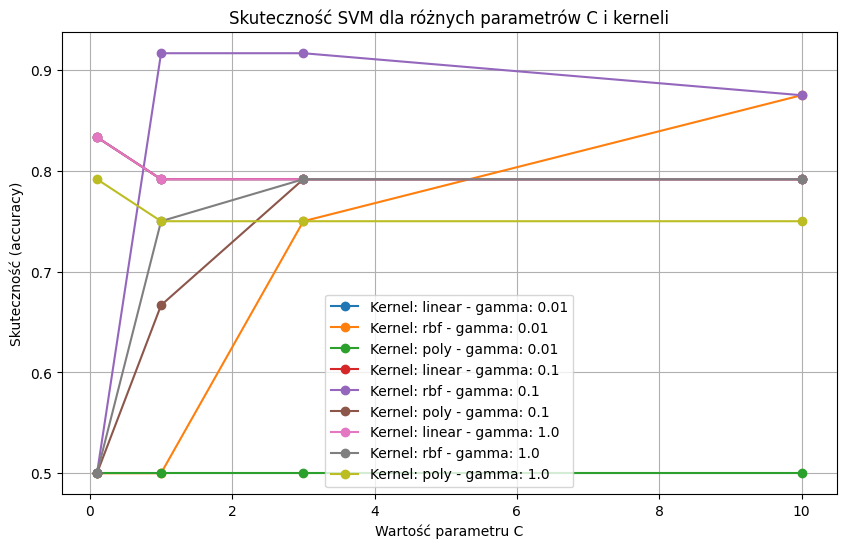

In [228]:
#YOUR CODE HERE

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Parametry do testowania
C_values = [0.1, 1, 3, 10]
gamma_values = [0.01, 0.1, 1]
kernels = ['linear', 'rbf', 'poly']

# Przechowywanie wyników
results = []

# Testowanie różnych kombinacji hiperparametrów
for C in C_values:
    for gamma in gamma_values:
        for kernel in kernels:
            svc = SVC(C=C, gamma=gamma, kernel=kernel)
            svc.fit(X_train, y_train)  # Trenowanie modelu
            
            y_pred = svc.predict(X_test)  # Predykcja na zbiorze testowym
            accuracy = accuracy_score(y_test, y_pred)  # Skuteczność modelu
            
            results.append({'C': C, 'gamma': gamma, 'kernel': kernel, 'accuracy': accuracy})

# Konwersja wyników na DataFrame
results_df = pd.DataFrame(results)

# Wizualizacja skuteczności modeli
plt.figure(figsize=(10, 6))
for (kernel, gamma) in results_df[["kernel", "gamma"]].drop_duplicates().itertuples(index=False):
    subset = results_df[(results_df["kernel"] == kernel) & (results_df["gamma"] == gamma)]
    plt.plot(subset["C"], subset["accuracy"], marker="o", linestyle="-", label=f"Kernel: {kernel} - gamma: {gamma}")

plt.xlabel('Wartość parametru C')
plt.ylabel('Skuteczność (accuracy)')
plt.title('Skuteczność SVM dla różnych parametrów C i kerneli')
plt.legend()
plt.grid(True)
plt.show()

## Zadanie 10

Należy wyznaczyć macierze pomyłek dla klasyfikatora. Proszę dokonać wizualizacji wraz z kolorami na wykresie. Przykłady: 

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix

https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html#sphx-glr-auto-examples-model-selection-plot-confusion-matrix-py

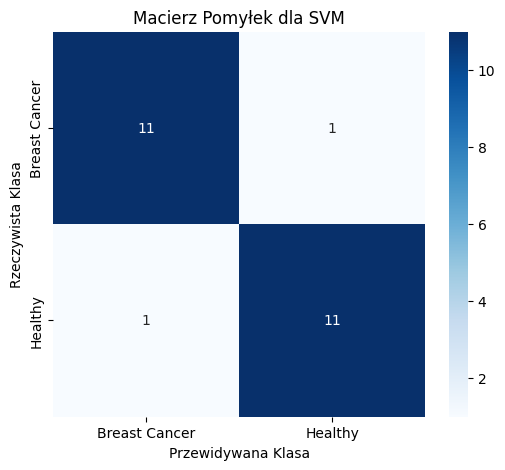

In [229]:
#YOUR CODE HERE

from sklearn.metrics import confusion_matrix
import seaborn as sns
# Trenowanie SVM (z wybranymi parametrami)
best_svc = SVC(C=1, kernel='rbf', gamma='scale')
best_svc.fit(X_train, y_train)

# Predykcja na zbiorze testowym
y_pred = best_svc.predict(X_test)

# Obliczenie macierzy pomyłek
cm = confusion_matrix(y_test, y_pred)

# Wizualizacja macierzy pomyłek
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Breast Cancer', 'Healthy'], yticklabels=['Breast Cancer', 'Healthy'])
plt.xlabel('Przewidywana Klasa')
plt.ylabel('Rzeczywista Klasa')
plt.title('Macierz Pomyłek dla SVM')
plt.show()